## Parte 4: Geoestadística y Análisis Avanzado 

# Parte 4: Geoestadística y análisis avanzado 

Este notebook aborda la generación de superficies continuas de predicción a partir de los datos puntuales (manzanas) del *Dataset Integrado*.

### Este análisis incluye:
1. **Semivariogramas** de variables continuas principales
2. **Interpolación espacial** (Kriging vs IDW comparación)
3. **Superficies de predicción** con medidas de incertidumbre
4. **Validación cruzada** de modelos de interpolación
5. **Análisis de anisotropía** si aplicalica

In [2]:
#!pip install geopandas numpy pandas scikit-gstat pykrige rasterio shapely matplotlib scipy seaborn python-dotenv sqlalchemy

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
import json

# Librerías de Geoestadística (Requisito de la parte 4)
from skgstat import Variogram, DirectionalVariogram # Para análisis de anisotropía y semivariogramas
from pykrige.ok import OrdinaryKriging # Para interpolación Kriging (Kriging Ordinario)
from scipy.spatial import cKDTree # Para interpolación IDW (Inverse Distance Weighting)

# Métricas de Validación (Requisito: Validación cruzada)
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Manejo de Rasters (Para guardar superficies de predicción)
import rasterio
from rasterio.transform import from_origin
from rasterio.crs import CRS

# --- CONFIGURACIÓN DE RUTAS DE SALIDA ---
BASE_DIR = Path('..')
OUTPUTS_DIR = BASE_DIR / 'outputs'
FIG_DIR = OUTPUTS_DIR / 'figures'
MODELS_DIR = OUTPUTS_DIR / 'models'
REPORTS_DIR = OUTPUTS_DIR / 'reports'

# Crear carpetas si no existen
for d in [FIG_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"✔ Directorio verificado: {d}")

# Configuración visual
sns.set_context("notebook")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 12)

# Cargar variables de entorno y conexión BD PostGIS
load_dotenv()
DB_USER = os.getenv('POSTGRES_USER', 'geouser')
DB_PASS = os.getenv('POSTGRES_PASSWORD', 'geopass')
DB_HOST = os.getenv('POSTGRES_HOST', 'localhost')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'geodatabase')

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("✔ Conexión a PostGIS establecida")

✔ Directorio verificado: ../outputs/figures
✔ Directorio verificado: ../outputs/models
✔ Directorio verificado: ../outputs/reports
✔ Conexión a PostGIS establecida


In [3]:
import rasterio
from rasterio.mask import mask

print("✔ Cargando y unificando tablas procesadas...")

# 1. Carga de tablas (Dataset Integrado)
gdf = gpd.read_postgis("SELECT * FROM processed_data.manzanas_atributos", engine, geom_col='geometry')
df_net = pd.read_sql("SELECT * FROM processed_data.metrics_network", engine)
df_env = pd.read_sql("SELECT * FROM processed_data.metrics_manzanas", engine)

# Carga auxiliar de Uso de Suelo
# (Hacemos un truco: agrupamos por manzana y nos quedamos con el uso de suelo principal si hay solapamiento)
df_usos = pd.read_sql("SELECT manzent, nom FROM processed_data.manzanas_uso_suelo", engine)
# Si una manzana toca dos usos, nos quedamos con el primero para simplificar el análisis maestro
df_usos = df_usos.drop_duplicates(subset='manzent')

# Conversión de llaves para el Join
gdf['manzent'] = gdf['manzent'].astype(str)
df_net['manzent'] = df_net['manzent'].astype(str)
df_env['manzent'] = df_env['manzent'].astype(str)
df_usos['manzent'] = df_usos['manzent'].astype(str)

# --- MERGES (Unificación) ---
gdf_master = gdf.merge(df_net, on='manzent', how='left')
# Unir Entorno
cols_env = [c for c in df_env.columns if c not in gdf_master.columns and c != 'manzent']
gdf_master = gdf_master.merge(df_env[['manzent'] + cols_env], on='manzent', how='left')
# Unir Uso de Suelo (Columna 'nom')
gdf_master = gdf_master.merge(df_usos[['manzent', 'nom']], on='manzent', how='left')

# Limpieza de nulos (Esencial para Kriging, no tolera NaNs)
fill_cols = ['degree_mean', 'betweenness_mean', 'road_length_m', 'road_density_km2', 'num_edificios', 'num_amenidades']
for c in fill_cols:
    if c in gdf_master.columns:
        gdf_master[c] = gdf_master[c].fillna(0)
        
# Rellenar nulos categóricos
gdf_master['nom'] = gdf_master['nom'].fillna('Sin Clasificar')

gdf_master['pop_density'] = gdf_master['total_personas'] / (gdf_master.geometry.area / 10000)

# --- ESTADÍSTICAS ZONALES RASTER ---
# --- FUNCIÓN AUXILIAR: ESTADÍSTICAS ZONALES ---
def calculate_zonal_stats(gdf, raster_path):
    """
    Descripción: Función que extrae valores promedio de un raster para cada polígono.
    Lo que es necesario para tener variables continuas comparables.
    
    Entradas:
        gdf (GeoDataFrame): Polígonos de manzanas.
        raster_path (str): Ruta al archivo TIF.
        
    Salidas:
        list: Valores promedio por manzana.
    """
    if not os.path.exists(raster_path): return np.nan
    means = []
    with rasterio.open(raster_path) as src:
        gdf_proj = gdf.to_crs(src.crs) if gdf.crs != src.crs else gdf
        for geom in gdf_proj.geometry:
            try:
                out_image, _ = mask(src, [geom], crop=True, nodata=np.nan)
                data = out_image[0][(out_image[0] != src.nodata) & (~np.isnan(out_image[0]))]
                means.append(np.mean(data) if data.size > 0 else 0)
            except: means.append(0)
    return means
# Calcular variables ambientales
gdf_master['ndvi_mean'] = calculate_zonal_stats(gdf_master, '../data/processed/sentinel2_ndvi.tif')
gdf_master['slope_mean'] = calculate_zonal_stats(gdf_master, '../data/processed/slope.tif')

print(f"✔ Dataset Maestro Actualizado: {len(gdf_master)} manzanas.")
print("   Incluye columna 'nom' para análisis de Uso de Suelo.")

✔ Cargando y unificando tablas procesadas...
✔ Dataset Maestro Actualizado: 792 manzanas.
   Incluye columna 'nom' para análisis de Uso de Suelo.


In [15]:
# Mostrar nombres de columnas
print(gdf_master.columns.tolist())

# Mostrar las primeras 10 filas
print(gdf_master.head(10))

['fid', 'cut', 'region_x', 'provincia_x', 'comuna_x', 'nombre_distrito', 'codigo_distrito', 'manzent', 'zona_censal', 'manzana', 'total_personas', 'total_hombres', 'total_mujeres', 'personas_0_a_5_años', 'personas_6_a_14_años', 'personas_15_a_64_años', 'personas_mas_65_años', 'personas_emigrantes', 'pueblos_indigena_originario', 'total_viv_particulares', 'total_viv_colectivas', 'viv_ocupa_morador_presente', 'total_viviendas', 'cantidad_hogares', 'viv_tipo_casa', 'viv_tipo_depto', 'viv_tipo_trad_indigena', 'viv_tipo_pieza', 'viv_tipo_mediagua', 'viv_tipo_movil', 'viv_tipo_otro_tipo', 'viv_pared_hormigon_armado', 'viv_pared_albañileria', 'viv_pared_tabique_forrado', 'viv_pared_tabique_sin_forro', 'viv_pared_adobe_barro', 'viv_pared_material_precario', 'viv_techo_tejas', 'viv_techo_losa_hormigon', 'viv_techo_planchas', 'viv_techo_fonolita', 'viv_techo_paja', 'viv_techo_mat_precarios', 'viv_techo_sin_cubierta_solida', 'viv_piso_parquet_flotante', 'viv_piso_radier', 'viv_piso_baldosa', 'viv

### Funciones auxiliares y flujo de análisis geoestadístico


Parámetros del variograma
  variable: pop_density
  model: spherical
  nugget: 1748.476319772282
  sill: 12218.788870427858
  range: 0.0
  bins_count: 12


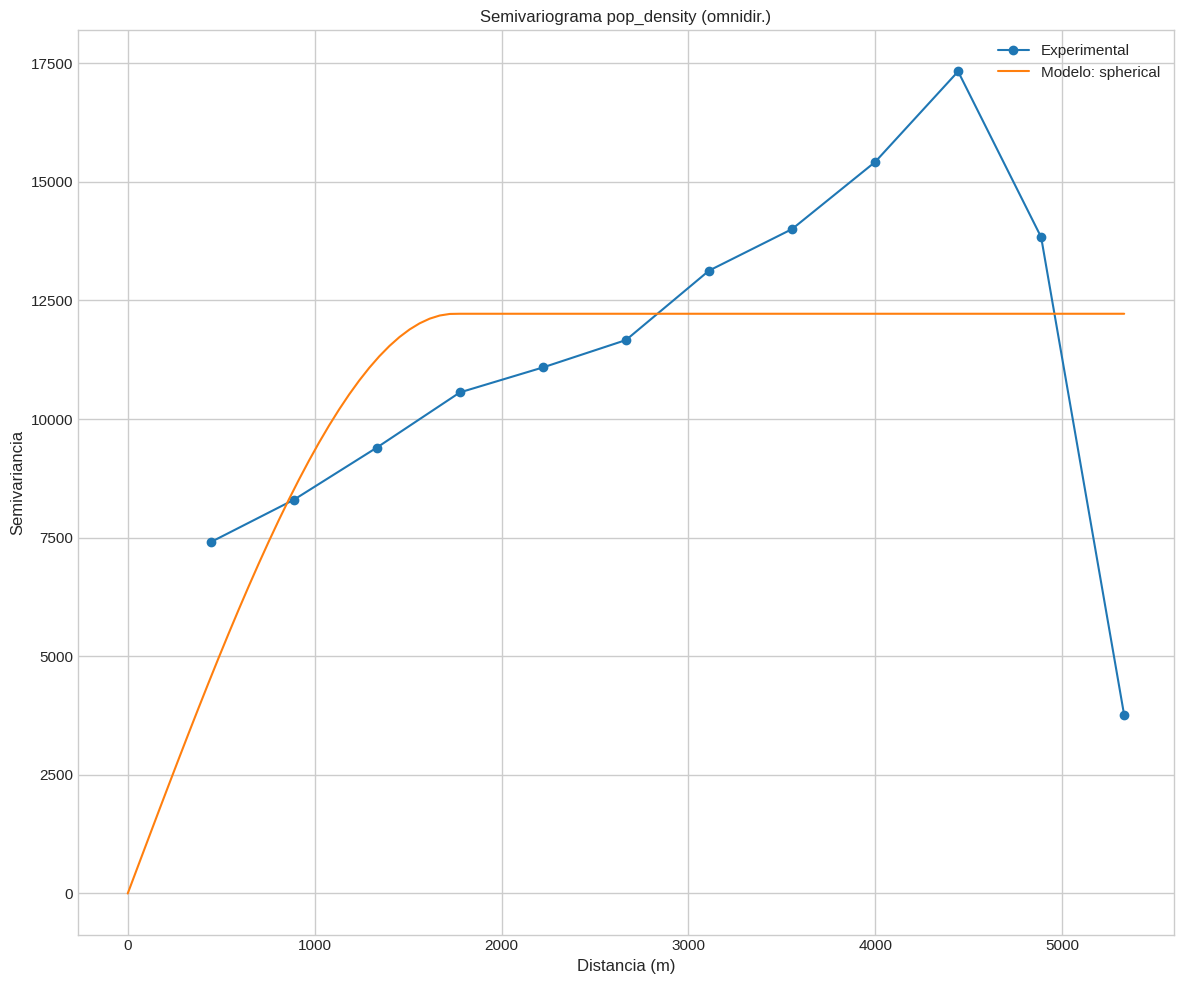


Variograma experimental (primeras filas)
   distance_bin_m         gamma
0      444.288328   7406.120178
1      888.576655   8297.810743
2     1332.864983   9398.358153
3     1777.153310  10560.990562
4     2221.441638  11087.437620

Resumen estadístico:
       distance_bin_m         gamma
count       12.000000     12.000000
mean      2887.874129  11323.301992
std       1601.904346   3762.433552
min        444.288328   3758.052331
25%       1666.081228   9123.221300
50%       2887.874129  11375.878022
75%       4109.667030  13875.583135
max       5331.459931  17326.175406

Kriging pop_density
Predicción:
  min=93.247, max=333.182, mean=163.604
Varianza:
  min=6894.097, max=8390.416, mean=7165.070


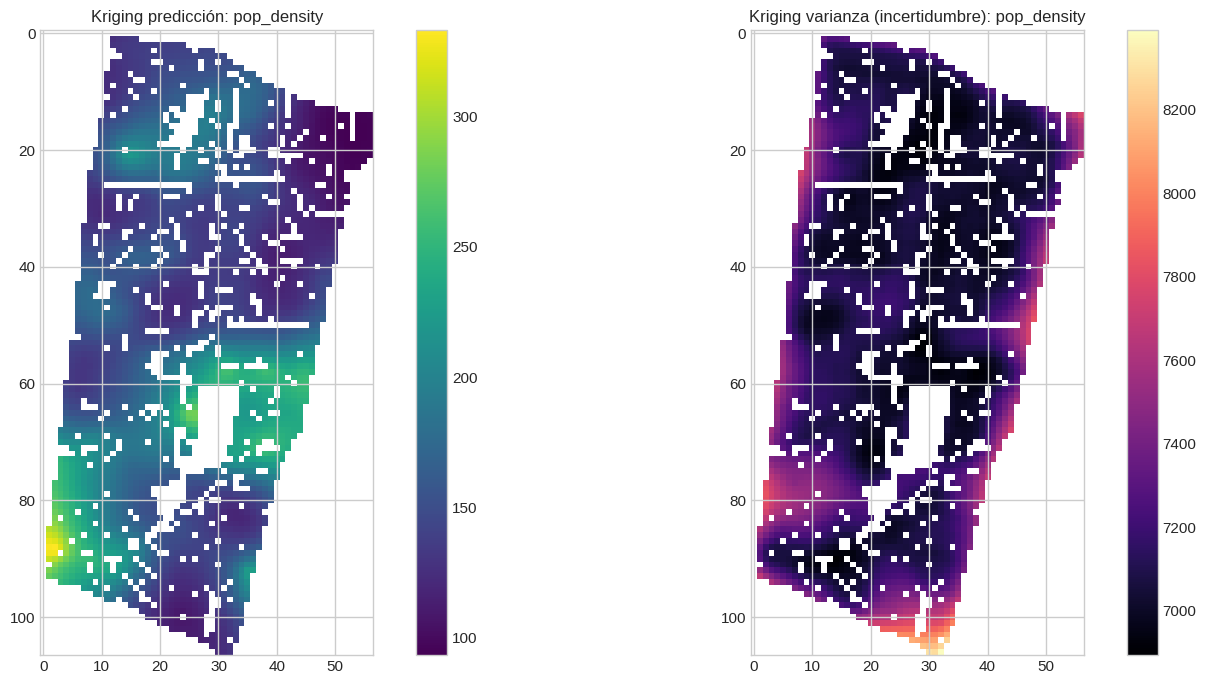


IDW pop_density
  min=1.304, max=838.807, mean=163.783


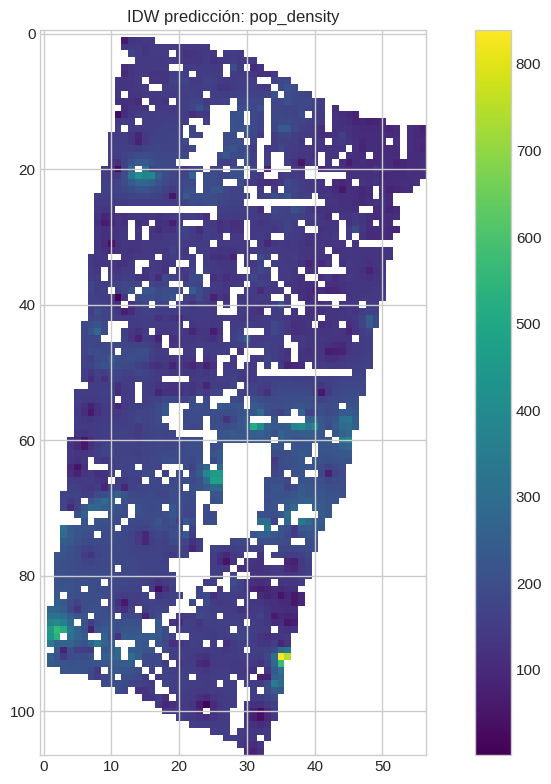


Validación cruzada
   fold   method        MAE        RMSE        R2     variable
0     1  Kriging  53.585138   84.360363  0.202346  pop_density
1     1      IDW  52.711836   82.897048  0.229778  pop_density
2     2  Kriging  50.588420   74.754716  0.269170  pop_density
3     2      IDW  49.665324   71.828843  0.325259  pop_density
4     3  Kriging  62.165451  113.647671  0.082219  pop_density
5     3      IDW  58.576825  106.680120  0.191305  pop_density
6     4  Kriging  63.305639  108.012080  0.134043  pop_density
7     4      IDW  60.817006  103.262749  0.208521  pop_density
8     5  Kriging  55.380865   84.651397  0.218663  pop_density
9     5      IDW  52.070512   76.850899  0.356027  pop_density

Resumen por método:
               MAE       RMSE        R2
method                                 
IDW      54.768301  88.303932  0.262178
Kriging  57.005103  93.085245  0.181288

Parámetros del variograma
  variable: ndvi_mean
  model: spherical
  nugget: 2017.2594243834187
  sill: 0

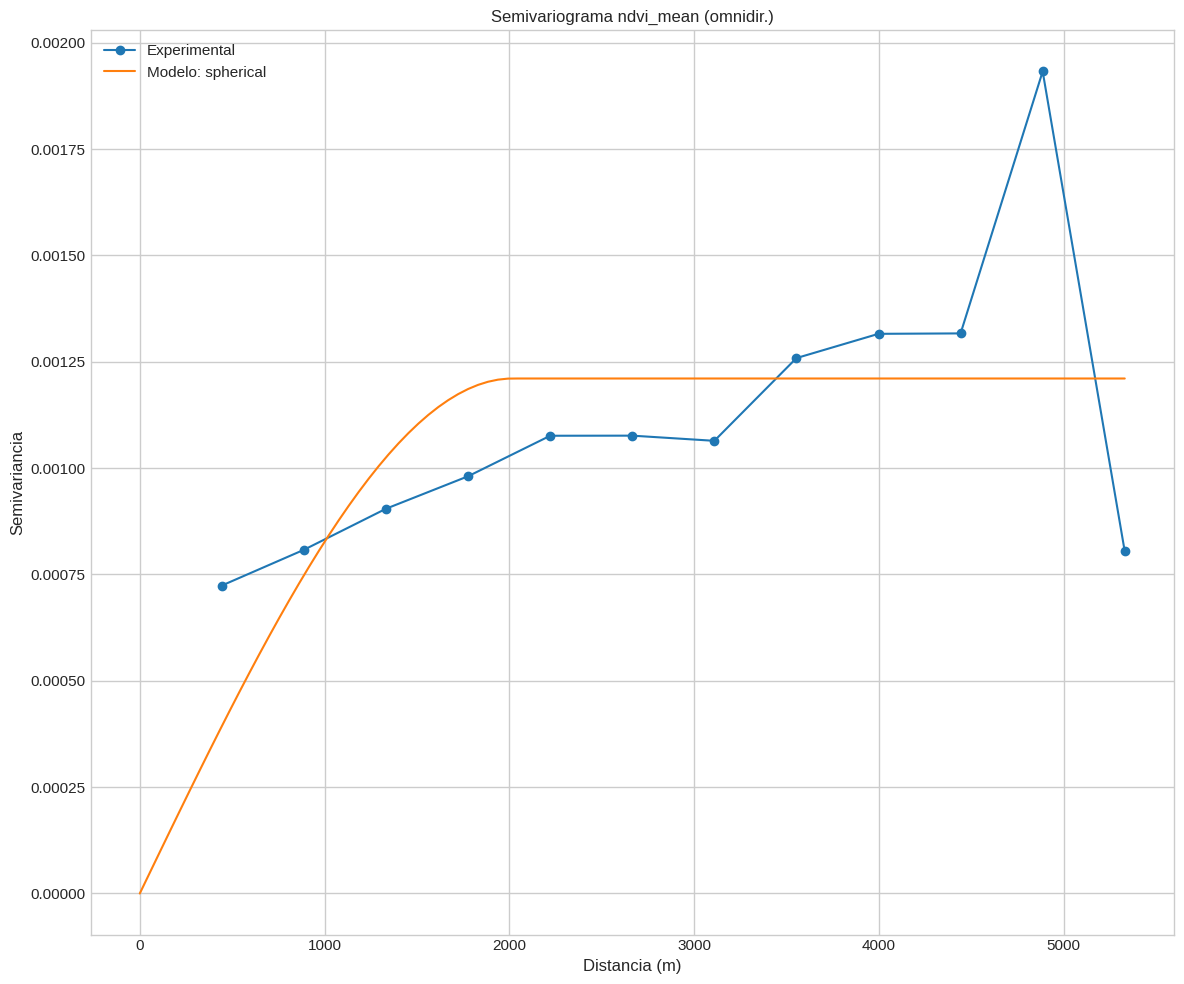


Variograma experimental (primeras filas)
   distance_bin_m     gamma
0      444.288328  0.000724
1      888.576655  0.000808
2     1332.864983  0.000905
3     1777.153310  0.000981
4     2221.441638  0.001076

Resumen estadístico:
       distance_bin_m      gamma
count       12.000000  12.000000
mean      2887.874129   0.001105
std       1601.904346   0.000328
min        444.288328   0.000724
25%       1666.081228   0.000880
50%       2887.874129   0.001070
75%       4109.667030   0.001273
max       5331.459931   0.001933

Kriging ndvi_mean
Predicción:
  min=0.045, max=0.133, mean=0.079
Varianza:
  min=0.001, max=0.001, mean=0.001


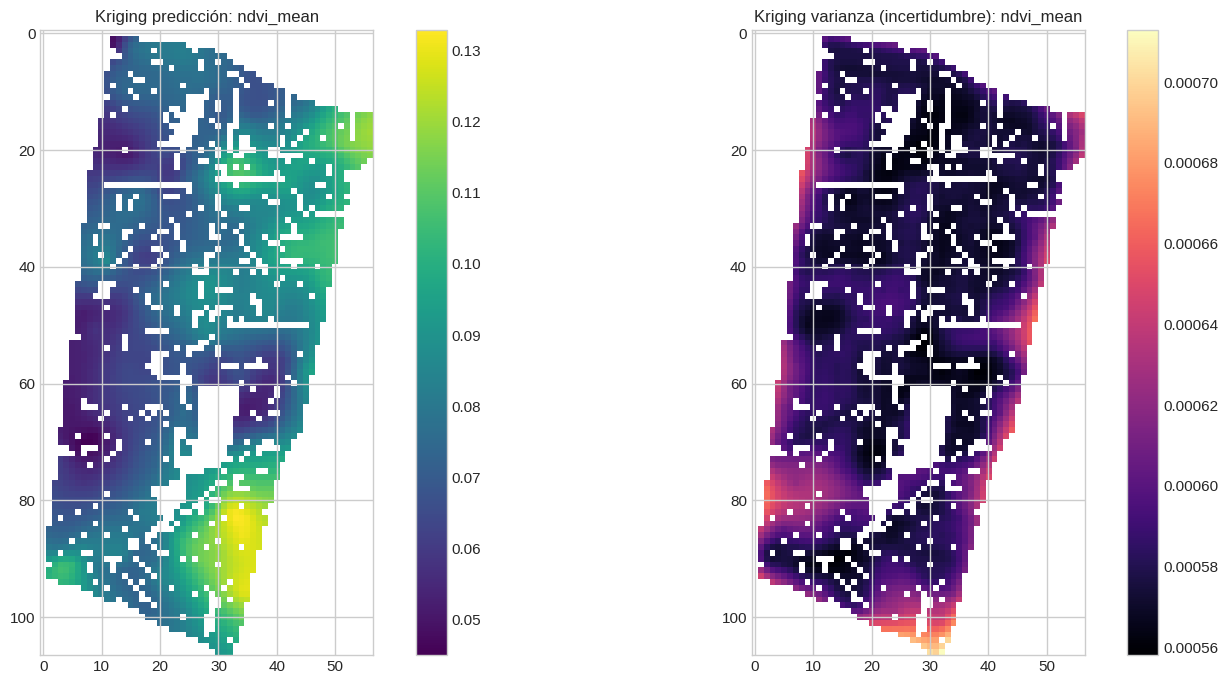


IDW ndvi_mean
  min=0.000, max=0.238, mean=0.079


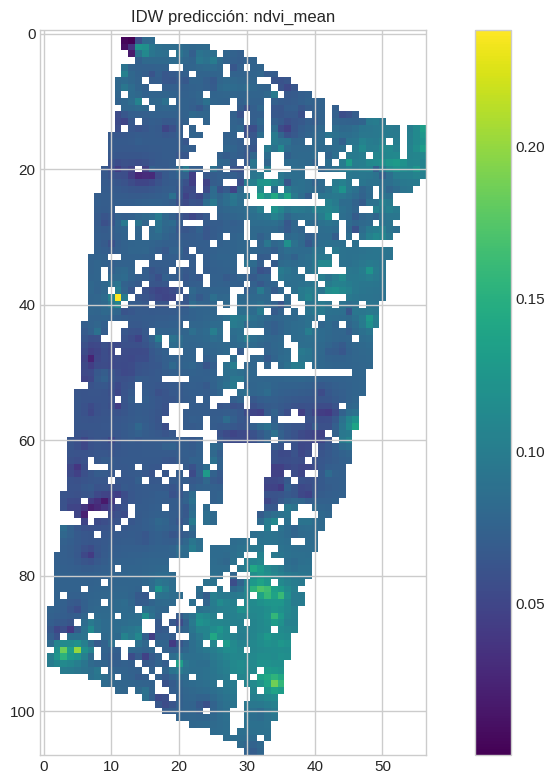


Validación cruzada
   fold   method       MAE      RMSE        R2   variable
0     1  Kriging  0.019562  0.027409  0.343883  ndvi_mean
1     1      IDW  0.020253  0.028194  0.305762  ndvi_mean
2     2  Kriging  0.018522  0.023158  0.245098  ndvi_mean
3     2      IDW  0.016752  0.021211  0.366674  ndvi_mean
4     3  Kriging  0.021044  0.028415  0.315626  ndvi_mean
5     3      IDW  0.020308  0.027663  0.351373  ndvi_mean
6     4  Kriging  0.017655  0.023579  0.322144  ndvi_mean
7     4      IDW  0.016983  0.022675  0.373082  ndvi_mean
8     5  Kriging  0.022292  0.031444  0.043684  ndvi_mean
9     5      IDW  0.019663  0.028702  0.203191  ndvi_mean

Resumen por método:
              MAE      RMSE        R2
method                               
IDW      0.018792  0.025689  0.320016
Kriging  0.019815  0.026801  0.254087

Parámetros del variograma
  variable: slope_mean
  model: spherical
  nugget: 5331.459931008187
  sill: 113.19037866437152
  range: 0.0
  bins_count: 12


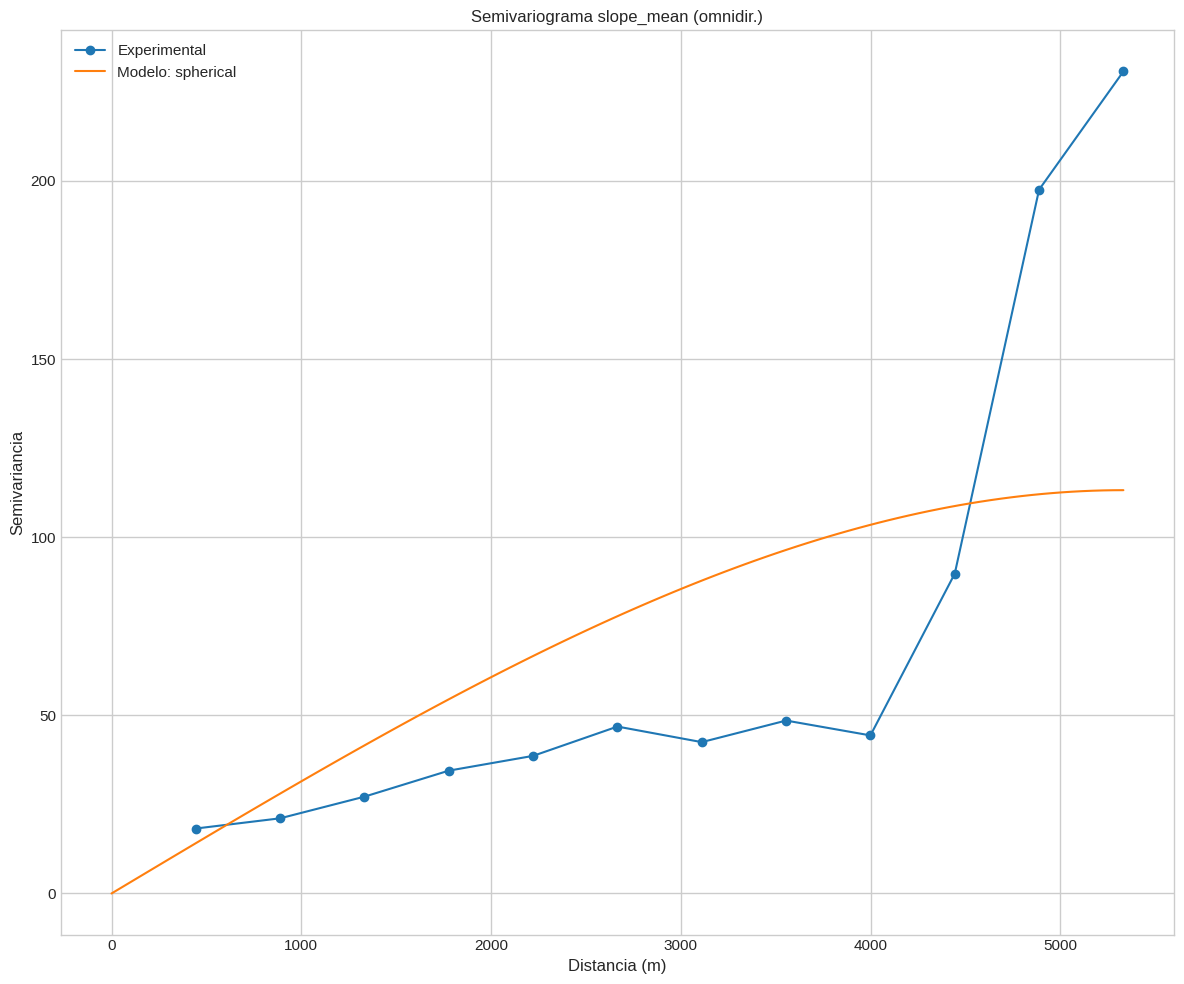


Variograma experimental (primeras filas)
   distance_bin_m      gamma
0      444.288328  18.229614
1      888.576655  21.098063
2     1332.864983  27.176830
3     1777.153310  34.473624
4     2221.441638  38.622743

Resumen estadístico:
       distance_bin_m       gamma
count       12.000000   12.000000
mean      2887.874129   69.984630
std       1601.904346   70.093959
min        444.288328   18.229614
25%       1666.081228   32.649426
50%       2887.874129   43.419300
75%       4109.667030   58.839838
max       5331.459931  230.708158

Kriging slope_mean
Predicción:
  min=0.766, max=27.906, mean=3.732
Varianza:
  min=8.806, max=14.402, mean=10.162


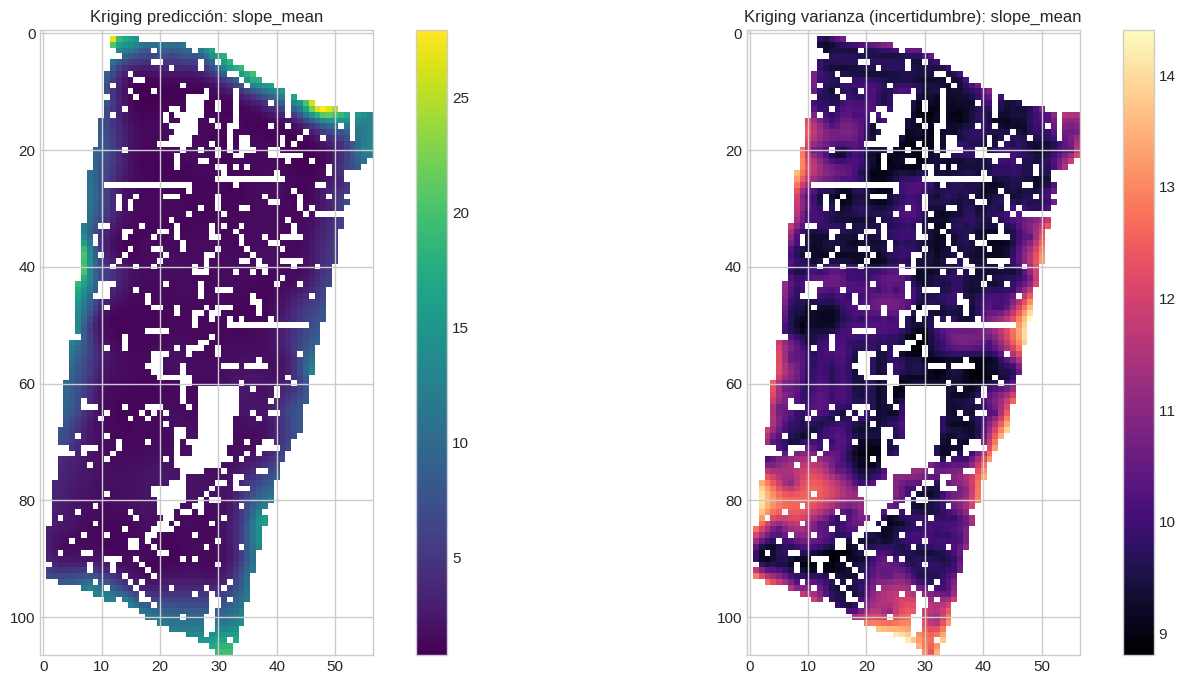


IDW slope_mean
  min=0.686, max=60.582, mean=3.065


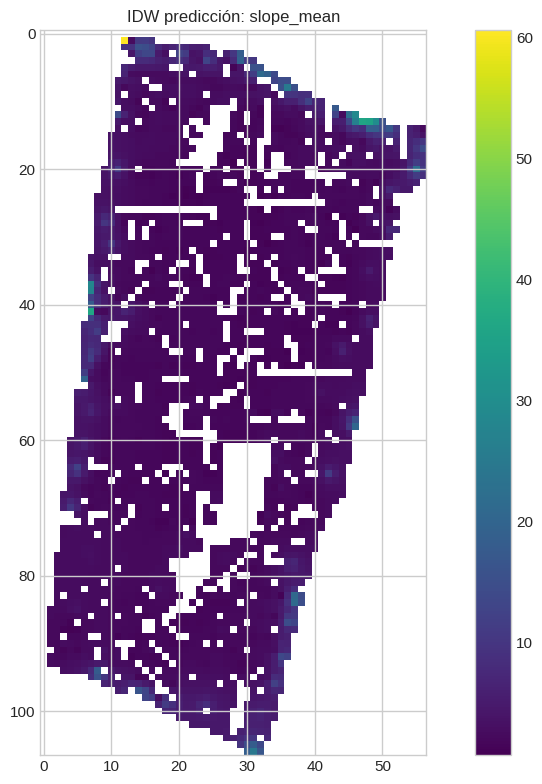


Validación cruzada
   fold   method       MAE      RMSE        R2    variable
0     1  Kriging  1.999125  4.725640  0.453560  slope_mean
1     1      IDW  1.869047  5.121656  0.358138  slope_mean
2     2  Kriging  1.380506  2.879002  0.285396  slope_mean
3     2      IDW  1.364928  3.089140  0.177271  slope_mean
4     3  Kriging  2.070925  4.965831  0.337276  slope_mean
5     3      IDW  2.250167  5.467555  0.196594  slope_mean
6     4  Kriging  2.173246  6.122913  0.304392  slope_mean
7     4      IDW  2.136073  6.505092  0.214846  slope_mean
8     5  Kriging  2.662124  5.956861 -0.038798  slope_mean
9     5      IDW  2.512115  6.128642 -0.099574  slope_mean

Resumen por método:
              MAE      RMSE        R2
method                               
IDW      2.026466  5.262417  0.169455
Kriging  2.057185  4.930050  0.268365
✔ Pipeline completado.


In [4]:
sns.set_context("notebook")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)

# --- CONFIG PARÁMETROS ---
# Variables continuas seleccionadas para interpolación (superficies de predicción)
VARIABLES_CONTINUAS = ['pop_density', 'ndvi_mean', 'slope_mean']
# Sistema de Coordenadas Proyectado (UTM 19S) para cálculos métricos precisos
TARGET_CRS = CRS.from_epsg(32719)
# Resolución de la malla de interpolación en metros (píxel de salida)
GRID_RESOLUTION = 50
# Número de pliegues para validación cruzada (K-Fold)
N_FOLDS = 5
# Exponente para ponderación inversa de distancia (IDW), estándar es 2
IDW_POWER = 2
# Umbral mínimo de puntos para ajustar modelos variográficos estables
MIN_POINTS = 20

# --- UTILIDADES ESPACIALES ---
def ensure_projected(gdf, target_crs=TARGET_CRS):
    """
    Descripción: Función que verifica y transforma la proyección del GeoDataFrame a un sistema métrico (UTM).
    La cual es útil para que las distancias en variogramas e interpolación sean en metros, no grados.

    Entradas:
        gdf (GeoDataFrame): Capa vectorial de entrada.
        target_crs (CRS): Sistema de coordenadas objetivo (default: EPSG:32719).

    Salidas:
        GeoDataFrame: Capa reproyectada.
    """
    if gdf.crs is None:
        raise ValueError("gdf_master no tiene CRS definido.")
    if gdf.crs != target_crs: # Si el CRS actual difiere del objetivo, reproyectar
        return gdf.to_crs(target_crs)
    return gdf

def centroids_from_polygons(gdf):
    """
    Descripción: Función que convierte geometrías poligonales (manzanas) a puntos (centroides).
    Ya que Kriging e IDW requieren datos puntuales para la interpolación.

    Entradas:
        gdf (GeoDataFrame): Capa de polígonos.

    Salidas:
        GeoDataFrame: Capa de puntos (centroides).
    """
    gdf_pts = gdf.copy()
    # Calcular el centroide geométrico de cada polígono
    gdf_pts['geometry'] = gdf_pts.geometry.centroid
    return gdf_pts

def build_grid(gdf_pts, resolution=GRID_RESOLUTION):
    """
    Descripción: Función que construye una malla regular (grid) basada en la extensión espacial de los datos (extent del bounding box).
    La cual define en dónde se realizarán las predicciones.

    Entradas:
        gdf_pts (GeoDataFrame): Datos puntuales para calcular límites (bounding box).
        resolution (int): Tamaño del píxel en metros.

    Salidas:
        tuple: (grid_x, grid_y, xs, ys) Matrices 2D de coordenadas y arreglos 1D.
    """
    # Obtener extensión total (minx, miny, maxx, maxy)
    bounds = gdf_pts.total_bounds  # minx, miny, maxx, maxy
    minx, miny, maxx, maxy = bounds
    # Agregar margen (padding) para evitar efectos de borde en la interpolación
    pad = resolution * 1
    minx -= pad; miny -= pad; maxx += pad; maxy += pad
    # Generar secuencia de coordenadas
    xs = np.arange(minx, maxx, resolution)
    ys = np.arange(miny, maxy, resolution)
    # Crear malla 2D
    grid_x, grid_y = np.meshgrid(xs, ys)
    return grid_x, grid_y, xs, ys

def mask_grid_to_union_polygon(gdf, grid_x, grid_y):
    """
    Descripción: Función que crea una máscara booleana para recortar la interpolación a la forma de la comuna.
    De esta forma, se evita predicciones en zonas vacías fuera de las manzanas censales.

    Entradas:
        gdf (GeoDataFrame): Capa de polígonos original.
        grid_x, grid_y (numpy.array): Mallas de coordenadas.

    Salidas:
        numpy.array: Matriz booleana (True dentro de la comuna, False fuera).
    """
    # Unificar todas las manzanas en un solo polígono gigante
    union_geom = gdf.unary_union
    # Convertir coordenadas del grid a objetos Point
    points = [Point(x, y) for x, y in zip(grid_x.ravel(), grid_y.ravel())]
    # Verificar contención punto a punto (costoso computacionalmente pero exacto)
    mask = np.array([union_geom.contains(pt) for pt in points]).reshape(grid_x.shape)
    return mask

# --- VARIOGRAMAS (ANÁLISIS DE CONTINUIDAD ESPACIAL) ---
def compute_variogram(coords, values, estimator='matheron', max_dist=None, n_lags=12):
    """
    Descripción: Función para ajustar un semivariograma experimental omnidireccional.
    Cuantificando cómo disminuye la similitud entre puntos al aumentar la distancia.

    Entradas:
        coords (numpy.array): Matriz Nx2 con coordenadas (X, Y).
        values (numpy.array): Arreglo N con valores de la variable.
        estimator (str): Estimador de semivarianza ('matheron' es robusto estándar).
        n_lags (int): Número de intervalos de distancia para calcular.

    Salidas:
        skgstat.Variogram: Objeto variograma ajustado.
    """
    # Calcular variograma sin normalizar para mantener unidades reales
    V = Variogram(coords, values, estimator=estimator, n_lags=n_lags, max_dist=max_dist, normalize=False)
    return V

def compute_directional_variograms(coords, values, angles=[0, 45, 90, 135], tolerance=22.5, n_lags=12, max_dist=None):
    """
    Descripción: Función que calcula variogramas direccionales para detectar anisotropía (cambios según la dirección).
    Por ejemplo, ¿la temperatura varía igual Norte-Sur que Este-Oeste?

    Entradas:
        angles (list): Ángulos en grados a evaluar.
        tolerance (float): Tolerancia angular para incluir pares de puntos.

    Salidas:
        dict: Diccionario {ángulo: Variograma}.
    """
    dir_vars = {}
    for a in angles:
        # Calcular variograma restringido a la dirección 'a'
        DV = DirectionalVariogram(coords, values, direction=a, tolerance=tolerance,
                                  n_lags=n_lags, max_dist=max_dist)
        dir_vars[a] = DV
    return dir_vars

def plot_variogram(V, title, save_path):
    """
    Descripción: Función que genera y guarda el gráfico del semivariograma experimental y su modelo ajustado.
    Permitiendo verificar visualmente la calidad del ajuste del modelo teórico (ej: Esférico).

    Entradas:
        V (skgstat.Variogram): Objeto variograma ya ajustado.
        title (str): Título del gráfico.
        save_path (str): Ruta completa donde se guardará la imagen (.png).

    Salidas:
        None: La función muestra y guarda la figura, no retorna valor.
    """
    fig, ax = plt.subplots()
    
    # Datos experimentales (Puntos)
    bins = V.bins
    gamma = V.experimental
    ax.plot(bins, gamma, 'o-', label='Experimental')
    
    # Modelo teórico ajustado (Curva suave)
    # Generamos 100 puntos para que la línea se vea fluida
    h = np.linspace(0, bins.max(), 100)
    ax.plot(h, V.fitted_model(h), '-', label=f'Modelo: {V.model.__name__}')
    
    # Configuración de etiquetas
    ax.set_xlabel('Distancia (m)')
    ax.set_ylabel('Semivariancia')
    ax.set_title(title)
    ax.legend()
    
    # Ajuste y guardado
    fig.tight_layout()
    plt.show()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)


def plot_directional_variograms(dir_vars, title, save_path):
    """
    Descripción: Función que grafica múltiples variogramas direccionales en una sola figura.
    La cual es útil para detectar anisotropía (si las curvas difieren mucho, hay dirección preferencial).

    Entradas:
        dir_vars (dict): Diccionario (ángulo: Variograma) generado por compute_directional_variograms.
        title (str): Título del gráfico.
        save_path (str): Ruta completa donde se guardará la imagen (.png).

    Salidas:
        None: La función guarda la figura en disco.
    """
    fig, ax = plt.subplots()
    
    # Iterar sobre cada dirección calculada
    for angle, DV in dir_vars.items():
        bins = DV.bins
        gamma = DV.experimental
        # Graficar cada dirección con una etiqueta distinta
        ax.plot(bins, gamma, 'o-', label=f'{angle}°')
    
    # Configuración de etiquetas
    ax.set_xlabel('Distancia (m)')
    ax.set_ylabel('Semivariancia')
    ax.set_title(title)
    ax.legend()
    
    # Ajuste y guardado sin mostrar en pantalla (para loops largos es más rápido)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)

# --- KRIGING (INTERPOLACIÓN ESTOCÁSTICA) ---
def ordinary_kriging(coords, values, grid_x, grid_y, variogram_model='spherical'):
    """
    Descripción: Función que ejecuta Interpolación Kriging Ordinario (OK) usando PyKrige.
    OK es el estimador lineal insesgado óptimo (BLUE) que minimiza la varianza del error.

    Entradas:
        coords (numpy.array): Coordenadas de entrenamiento.
        values (numpy.array): Valores de entrenamiento.
        grid_x, grid_y (numpy.array): Mallas de coordenadas destino.
        variogram_model (str): Modelo teórico ('spherical', 'gaussian', etc.).

    Salidas:
        tuple: (z_pred, ss_pred): Predicciones y Varianza de interpolación (incertidumbre).
    """
    ok = OrdinaryKriging(
        coords[:,0], coords[:,1], values,
        variogram_model=variogram_model,
        enable_plotting=False,
        coordinates_type='euclidean'
    )
    # Ejecutar en modo grid (produce matriz 2D)
    # Nota: pykrige espera vectores 1D para los ejes X e Y del grid
    z, ss = ok.execute('grid', grid_x[0,:], grid_y[:,0])
    return np.array(z), np.array(ss)

# --- IDW (INTERPOLACIÓN DETERMINISTA) ---
def idw_interpolation(coords, values, grid_x, grid_y, power=IDW_POWER, eps=1e-12):
    """
    Descripción: Función que realiza interpolación por Distancia Inversa Ponderada (IDW).
    Método determinista simple: más cerca significa más influencia.

    Entradas:
        power (int): Potencia de ponderación (mayor potencia = más local).
        eps (float): Epsilon para evitar división por cero.

    Salidas:
        numpy.array: Matriz interpolada 2D.
    """
    # Crear índice espacial KDTree para búsqueda rápida de vecinos
    tree = cKDTree(coords)
    # Aplanar grid para consulta masiva
    gx = grid_x.ravel(); gy = grid_y.ravel()
    # Calcular distancias a TODOS los puntos conocidos
    dists, idxs = tree.query(np.vstack([gx, gy]).T, k=coords.shape[0], workers=-1)
    # Calcular pesos (inverso de la distancia elevado a la potencia)
    weights = 1.0 / (dists**power + eps)
    # Normalizar pesos
    wsum = np.sum(weights, axis=1)
    # Promedio ponderado
    z = np.sum(weights * values[idxs], axis=1) / wsum
    # Retornar a forma de matriz
    return z.reshape(grid_x.shape)

# --- EXPORTACIÓN RASTER ---
def save_raster(array, xs, ys, crs, out_path, nodata=np.nan):
    """
    Descripción: Función que guarda una matriz numpy como archivo GeoTIFF georreferenciado.
    
    Entradas:
        array (numpy.array): Datos a guardar.
        xs, ys (numpy.array): Coordenadas X e Y (1D).
        crs (CRS): Sistema de referencia.
        out_path (str): Ruta de salida.
    """
    # Calcular tamaño de píxel
    pixel_size_x = xs[1] - xs[0]
    pixel_size_y = ys[1] - ys[0]
    # Crear transformación afín (origen en esquina superior izquierda)
    transform = from_origin(xs.min(), ys.max(), pixel_size_x, pixel_size_y)
    height, width = array.shape
    # Definir metadatos del GeoTIFF
    profile = {
        'driver': 'GTiff',
        'height': height,
        'width': width,
        'count': 1,
        'dtype': 'float32',
        'crs': crs,
        'transform': transform,
        'nodata': nodata
    }
    # Escribir archivo
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(array.astype('float32'), 1)

# --- VALIDACIÓN CRUZADA ---
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def cross_validate_interpolators(coords, values, n_splits=5, variogram_model='spherical', idw_power=IDW_POWER):
    """
    Descripción: Función que realiza Validación Cruzada (CV) espacial punto a punto 
    y compara Kriging vs IDW dividiendo los datos en conjuntos de entrenamiento y prueba.

    Entradas:
        n_splits (int): Número de folds (k-fold CV).

    Salidas:
        DataFrame: Tabla con métricas MAE, RMSE y R2 para cada fold y método.
    """
    # Inicializar K-Fold
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    records = []
    # Iterar sobre cada pliegue (fold)
    for fold, (tr_idx, te_idx) in enumerate(kf.split(coords)):
        # Separar datos: Entrenamiento (Train) vs Prueba (Test)
        Xtr, ytr = coords[tr_idx], values[tr_idx]
        Xte, yte = coords[te_idx], values[te_idx]

        # 1. Evaluar Kriging
        # Ajustar modelo con datos de entrenamiento
        ok = OrdinaryKriging(Xtr[:,0], Xtr[:,1], ytr, variogram_model=variogram_model,
                             enable_plotting=False, coordinates_type='euclidean')
        # Predecir en ubicaciones de prueba (modo 'points')
        z_k, ss_k = ok.execute('points', Xte[:,0], Xte[:,1])
        z_k = np.array(z_k)

        # 2. Evaluar IDW
        tree = cKDTree(Xtr)
        dists, idxs = tree.query(Xte, k=Xtr.shape[0], workers=-1)
        weights = 1.0 / (dists**idw_power + 1e-12)
        wsum = np.sum(weights, axis=1)
        z_idw = np.sum(weights * ytr[idxs], axis=1) / wsum

        # 3. Calcular Métricas de Error
        # Comparar valor real (yte) vs predicción (z_k / z_idw)
        mae_k = mean_absolute_error(yte, z_k)
        rmse_k = mean_squared_error(yte, z_k, squared=False)
        r2_k = r2_score(yte, z_k)

        mae_i = mean_absolute_error(yte, z_idw)
        rmse_i = mean_squared_error(yte, z_idw, squared=False)
        r2_i = r2_score(yte, z_idw)

        # Guardar resultados
        records.append({
            'fold': fold+1,
            'method': 'Kriging',
            'MAE': mae_k,
            'RMSE': rmse_k,
            'R2': r2_k
        })
        records.append({
            'fold': fold+1,
            'method': 'IDW',
            'MAE': mae_i,
            'RMSE': rmse_i,
            'R2': r2_i
        })

    return pd.DataFrame(records)

# --- PIPELINE PRINCIPAL (FLUJO DE EJECUCIÓN) ---
def run_pipeline(gdf_master, variables=VARIABLES_CONTINUAS, grid_resolution=GRID_RESOLUTION,
                 variogram_model='spherical'):
    """
    Descripción: Función que incluye todo el flujo de análisis geoestadístico:
    1. Preprocesamiento (Proyección y Centroides).
    2. Creación de malla de predicción (Grid).
    3. Iteración por variable:
       - Análisis Variográfico (Modelado de continuidad espacial).
       - Interpolación (Kriging Ordinario e IDW).
       - Generación de mapas (Rasters) y superficies de incertidumbre.
       - Validación cruzada comparativa (Evaluación de precisión).

    Entradas:
        gdf_master (GeoDataFrame): Dataset principal con geometrías (manzanas) y variables.
        variables (list): Lista de nombres de columnas a interpolar (ej: ['pop_density', 'ndvi_mean']).
        grid_resolution (int): Tamaño del píxel de salida en metros (default: 50).
        variogram_model (str): Modelo teórico para el semivariograma (default: 'spherical').

    Salidas:
        None: La función no retorna valor, pero genera múltiples archivos en disco:
              - outputs/figures/: Gráficos de variogramas y mapas de interpolación (PNG).
              - outputs/models/: Rasters de predicción e incertidumbre (TIF) y parámetros (JSON).
              - outputs/reports/: Tablas de validación cruzada y resumen (CSV/JSON).
    """
    # 1. Asegurar proyección métrica y convertir a puntos
    gdf_proj = ensure_projected(gdf_master)
    gdf_pts = centroids_from_polygons(gdf_proj)

    # 2. Construir Grid de predicción
    grid_x, grid_y, xs, ys = build_grid(gdf_pts, resolution=grid_resolution)
    # Crear máscara para recortar resultados a la comuna
    mask = mask_grid_to_union_polygon(gdf_proj, grid_x, grid_y)

    # 3. Procesar cada variable
    all_cv = []  # Lista para acumular resultados de validación
    for var in variables:
        # Limpieza de datos específica por variable
        dfv = gdf_pts[[var, 'geometry']].dropna().copy()
        # Algunas variables pueden tener valores no finitos
        dfv = dfv[np.isfinite(dfv[var])]
        # Verificar suficiencia de datos
        if dfv.shape[0] < MIN_POINTS:
            print(f"ADVERTENCIA: {var}: insuficiente ({dfv.shape[0]} puntos). Saltando.")
            continue
        # Extraer coordenadas y valores
        coords = np.vstack([dfv.geometry.x.values, dfv.geometry.y.values]).T
        values = dfv[var].values.astype(float)

        # --- A. Semivariograma omnidireccional ---
        V = compute_variogram(coords, values, n_lags=12)
        # Guardar parámetros del modelo ajustado (Nugget, Sill, Range)
        vario_params = {
            'variable': var,
            'model': V.model.__name__,
            'nugget': float(V.parameters[0]),
            'sill': float(V.parameters[1]),
            'range': float(V.parameters[2]),
            'bins_count': int(len(V.bins))
        }

        print("\nParámetros del variograma")
        for k, v in vario_params.items():
            print(f"  {k}: {v}")
        
        with open(os.path.join(MODELS_DIR, f'variogram_{var}.json'), 'w') as f:
            json.dump(vario_params, f, indent=2)

        # Graficar variograma experimental vs modelo
        plot_variogram(V, title=f"Semivariograma {var} (omnidir.)",
                       save_path=os.path.join(FIG_DIR, f'variogram_{var}.png'))

        # --- B. Anisotropía: variogramas direccionales ---
        dir_vars = compute_directional_variograms(coords, values)
        plot_directional_variograms(dir_vars, title=f"Semivariogramas direccionales {var}",
                                    save_path=os.path.join(FIG_DIR, f'directional_variograms_{var}.png'))

        # Guardar datos del variograma experimental (CSV)
        vario_report = pd.DataFrame({
            'distance_bin_m': V.bins,
            'gamma': V.experimental
        })

        print("\nVariograma experimental (primeras filas)")
        print(vario_report.head())
        print("\nResumen estadístico:")
        print(vario_report.describe())
        
        vario_report.to_csv(os.path.join(REPORTS_DIR, f'variogram_experimental_{var}.csv'), index=False)

        # --- C. Interpolación: Kriging Ordinario ---
        z_krig, ss_krig = ordinary_kriging(coords, values, grid_x, grid_y, variogram_model=V.model.__name__)
        # Aplicar máscara de la comuna
        z_krig_masked = np.where(mask, z_krig, np.nan)
        ss_krig_masked = np.where(mask, ss_krig, np.nan)

        print(f"\nKriging {var}")
        print("Predicción:")
        print(f"  min={np.nanmin(z_krig_masked):.3f}, "
              f"max={np.nanmax(z_krig_masked):.3f}, "
              f"mean={np.nanmean(z_krig_masked):.3f}")
        
        print("Varianza:")
        print(f"  min={np.nanmin(ss_krig_masked):.3f}, "
              f"max={np.nanmax(ss_krig_masked):.3f}, "
              f"mean={np.nanmean(ss_krig_masked):.3f}")

        # Guardar TIFs (Predicción e Incertidumbre)
        save_raster(z_krig_masked, xs, ys, gdf_proj.crs, os.path.join(MODELS_DIR, f'kriging_{var}.tif'))
        save_raster(ss_krig_masked, xs, ys, gdf_proj.crs, os.path.join(MODELS_DIR, f'kriging_variance_{var}.tif'))

        # Visualización Kriging
        fig, ax = plt.subplots(1, 2, figsize=(16, 7))
        im0 = ax[0].imshow(z_krig_masked, origin='upper', cmap='viridis')
        ax[0].set_title(f'Kriging predicción: {var}')
        plt.colorbar(im0, ax=ax[0])
        im1 = ax[1].imshow(ss_krig_masked, origin='upper', cmap='magma')
        ax[1].set_title(f'Kriging varianza (incertidumbre): {var}')
        plt.colorbar(im1, ax=ax[1])
        plt.tight_layout()
        plt.show()
        fig.savefig(os.path.join(FIG_DIR, f'kriging_{var}.png'), dpi=200)
        plt.close(fig)

        # --- D. Interpolación: IDW ---
        z_idw = idw_interpolation(coords, values, grid_x, grid_y, power=IDW_POWER)
        z_idw_masked = np.where(mask, z_idw, np.nan)

        save_raster(z_idw_masked, xs, ys, gdf_proj.crs, os.path.join(MODELS_DIR, f'idw_{var}.tif'))

        print(f"\nIDW {var}")
        print(f"  min={np.nanmin(z_idw_masked):.3f}, "
              f"max={np.nanmax(z_idw_masked):.3f}, "
              f"mean={np.nanmean(z_idw_masked):.3f}")
        # Visualización IDW
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(z_idw_masked, origin='upper', cmap='viridis')
        ax.set_title(f'IDW predicción: {var}')
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
        fig.savefig(os.path.join(FIG_DIR, f'idw_{var}.png'), dpi=200)
        plt.close(fig)

        # --- E. Validación Cruzada (Kriging vs IDW) ---
        cv_df = cross_validate_interpolators(coords, values, n_splits=N_FOLDS,
                                             variogram_model=V.model.__name__, idw_power=IDW_POWER)
        cv_df['variable'] = var
        print("\nValidación cruzada")
        print(cv_df)
        
        print("\nResumen por método:")
        print(cv_df.groupby('method')[['MAE', 'RMSE', 'R2']].mean())
        
        cv_df.to_csv(os.path.join(REPORTS_DIR, f'cv_{var}.csv'), index=False)
        all_cv.append(cv_df)

        # Reporte resumen JSON
        summary = {
            'variable': var,
            'kriging_model': V.model.__name__,
            'n_points': int(len(values)),
            'grid_resolution_m': GRID_RESOLUTION
        }
        with open(os.path.join(REPORTS_DIR, f'summary_{var}.json'), 'w') as f:
            json.dump(summary, f, indent=2)

    # Guardar consolidado de CV para todas las variables
    if all_cv:
        cv_all = pd.concat(all_cv, axis=0, ignore_index=True)
        cv_all.to_csv(os.path.join(REPORTS_DIR, 'cv_all_variables.csv'), index=False)
    print("✔ Pipeline completado.")

# --- EJECUCIÓN ---
# Lanzar el proceso para las variables continuas definidas al inicio
run_pipeline(gdf_master, variables=VARIABLES_CONTINUAS, grid_resolution=GRID_RESOLUTION)

## Resultados de geoestadística y análisis avanzado 

Las variables analizadas (densidad poblacional (pop_density), índice de vegetación NDVI (ndvi_mean) y pendiente media del terreno (slope_mean)) fueron seleccionadas porque representan dimensiones clave de la estructura territorial de la comuna. La densidad de población muestra dónde se concentran los habitantes y dónde hay menos gente. El NDVI refleja la presencia y el estado de la vegetación, útil para reconocer áreas verdes y espacios agrícolas. La pendiente del terreno describe la forma física del territorio, influyendo en dónde se construyen viviendas, la facilidad de acceso, los riesgos naturales y los usos del suelo.En conjunto, estas variables permiten integrar componentes sociales, ambientales y geomorfológicos, entregando una visión holística del comportamiento espacial de la comuna San Joaquín.

### 1. Resultados de los semivariogramas

Los semivariogramas muestran que las tres variables no están distribuidas al azar, sino que tienen cierta relación espacial. En todos los casos, los puntos cercanos se parecen más entre sí que los lejanos. Esto confirma que se pueden usar métodos como el kriging para hacer predicciones. Evaluando para cada variable analizada:

* Densidad de población: la semivarianza sube desde 7.406 hasta 17.326, con un promedio de 11.323. Este aumento refleja una gran diversidad espacial, coherente con la existencia de zonas muy densas y otras más vacías. El nugget alto (1748.47) indica que hay variaciones pequeñas que no se capturan bien o posibles errores de medición.

* NDVI: los valores son mucho más bajos (entre 0.000724 y 0.001933), lo que muestra una mayor continuidad espacial. El semivariograma es más suave y estable, lo que sugiere que la vegetación está distribuida de manera más homogénea que la población.

* Pendiente: los valores van de 18.23 a 230.70, con una dispersión grande (desviación estándar ≈ 70). Esto refleja un relieve variado, con sectores planos y otros abruptos. El semivariograma confirma que la pendiente está organizada espacialmente, pero con cambios bruscos propios de zonas con quiebres topográficos.

En resumen, los semivariogramas muestran que las tres variables tienen autocorrelación espacial y justifican el uso de interpolación.

### 2. Comparación de interpolación: Kriging versus IDW

Se aplicaron dos métodos: Kriging, que usa la relación espacial modelada, e IDW, que da más peso a los puntos cercanos.  Evaluando para cada variable analizada:

* Densidad de población: IDW tuvo mejores resultados (MAE=54.77, RMSE=88.30, R²=0.262) que Kriging (R²=0.181). Esto se debe a que la población está influenciada por valores extremos (zonas muy densas o muy vacías), que IDW conserva mejor. Kriging suaviza esos picos y pierde detalle.

* NDVI: ambos métodos fueron similares, con una ligera ventaja de IDW (R²=0.320 frente a 0.254). Esto ocurre porque el NDVI es bastante continuo y la distancia ya es un buen predictor.

* Pendiente: aquí Kriging fue mejor (R²=0.268 frente a 0.169 de IDW), además de menor RMSE. La pendiente depende más de la forma del terreno, y Kriging logra capturar mejor esa estructura.

En conclusión: IDW funciona mejor para población y vegetación, mientras que Kriging es más adecuado para la pendiente.

## 3. Superficies de predicción e incertidumbre

Las superficies de kriging obtenidas entregan tanto valores estimados como su varianza de predicción, lo que permite evaluar incertidumbre. Para densidad poblacional, los valores predichos se concentraron entre 93 y 333 habitantes, con varianzas entre 6894 y 8390. La incertidumbre más alta coincide con zonas con menos puntos muestreados o con mayor heterogeneidad interna, especialmente en transiciones urbano–rural.

En NDVI, los valores predichos oscilaron entre 0.045 y 0.133, lo cual se encuentra dentro de rangos típicos para zonas con vegetación moderada. La varianza fue casi constante (≈0.001), indicando alta estabilidad y confianza en la predicción, coherente con la continuidad espacial ya observada en el semivariograma.

Para la pendiente, los valores predichos se situaron entre 0.76° y 27.9°, con mayores incertidumbres en sectores de relieve abrupto. La relación entre pendiente alta e incremento de varianza es esperable, ya que pequeños errores de medición generan grandes diferencias en regiones montañosas.

## 4. Validación cruzada de los modelos de interpolación

La validación cruzada muestra que ninguno de los métodos presenta ajuste perfecto, lo cual es realista en datos territoriales complejos. En términos generales:

* los errores MAE y RMSE son moderados, lo que indica predicciones razonables

* los valores de R² son positivos pero bajos, mostrando que existe variabilidad no explicada
  
* en algunos pliegues de slope_mean se observan R² negativos, señalando sobreajuste local o presencia de outliers

En resumen:

* IDW funciona mejor para densidad poblacional y NDVI
  
* kriging funciona mejor para pendiente
  
* ambos métodos son complementarios más que excluyentes
  